# DSC 640 Data Presentation & Visualization

## DSC 640 Data Presentation & Visualization
___Term Project: National Childcare Prices___

___Date: 21 September 2025___

___Name: Suriyamurthy, Subash Karthick___

___Version: Milestone 1 - September 21___

___Version: Milestone 2 - October 05___

___Version: Milestone 3 - October 19___

For this project, I analyzed a sample from the National Database of Childcare Prices to understand its structure, key variables, and price distributions across the United States. The dataset provides detailed information at the county level, including data on states, counties, years, and various price measures for different types of childcare providers and age groups, such as infants, toddlers, and preschoolers, along with center-based and family care options. I generated descriptive statistics and visualizations to examine price distributions and regional differences.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import plotly.express as px

In [ ]:
#check versions of packages
print('pandas version:', pd.__version__)
print('numpy version:', np.__version__)
print('scikit-learn version:', sklearn.__version__)

pandas version: 2.2.2
numpy version: 2.0.2
scikit-learn version: 1.6.1


## Import the dataset into the project

In [ ]:
# Load dataset
file_path = "nationaldatabaseofchildcareprices.xlsx"
childcare_df = pd.read_excel(file_path, sheet_name="nationaldatabaseofchildcare")

## Exploration Data Analysis

In [ ]:
childcare_df.head()

,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.42,4.41,6.32,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.93,5.72,6.11,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.0,1.0
2,Alabama,AL,Autauga County,1001,2010,6.21,5.57,6.78,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.0,1.0
3,Alabama,AL,Autauga County,1001,2011,7.55,8.13,7.03,6.2,6.3,...,95.28,3.0,94.25,1.0,111.2,1.0,111.2,3.0,110.0,1.0
4,Alabama,AL,Autauga County,1001,2012,8.60,8.88,8.29,6.7,6.4,...,99.22,3.0,98.53,1.0,115.8,1.0,115.8,3.0,115.0,1.0


In [ ]:
childcare_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Columns: 227 entries, State_Name to _75FCCPreschool_flag
dtypes: float64(159), int64(65), object(3)
memory usage: 59.9+ MB


In [ ]:
childcare_df.shape

(34567, 227)

In [ ]:
childcare_df.columns

Index(['State_Name', 'State_Abbreviation', 'County_Name', 'County_FIPS_Code',
       'StudyYear', 'UNR_16', 'FUNR_16', 'MUNR_16', 'UNR_20to64',
       'FUNR_20to64',
       ...
       'MFCCToddler_flag', 'MFCCPreschool', 'MFCCPreschool_flag',
       '_75FCCInfant', '_75FCCInfant_flag', '_75FCCToddler',
       '_75FCCToddler_flag', '_75FCCPreschool', '_75FCCPreschool_flag',
       '_price_clean'],
      dtype='object', length=228)

In [ ]:
childcare_df.dtypes

,0
State_Name,object
State_Abbreviation,object
County_Name,object
County_FIPS_Code,int64
StudyYear,int64
...,...
_75FCCInfant_flag,float64
_75FCCToddler,float64
_75FCCToddler_flag,float64
_75FCCPreschool,float64


In [ ]:
childcare_df.describe()

,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,MUNR_20to64,FLFPR_20to64,FLFPR_20to64_Under6,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
count,34567.000000,34567.000000,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.00000,23383.000000,23383.000000
mean,30388.132786,2012.999711,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,...,106.759749,1.153359,104.189510,1.287859,128.909289,1.792841,120.784283,1.18800,117.897482,1.294316
std,15161.015383,3.162232,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,...,29.982431,0.532176,28.961701,0.696762,38.543010,0.818080,35.334666,0.58367,34.111188,0.708542
min,1001.000000,2008.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,...,43.080000,1.000000,40.030000,1.000000,50.000000,1.000000,50.000000,1.00000,46.450000,1.000000
25%,18177.000000,2010.000000,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,...,85.085000,1.000000,84.255000,1.000000,100.830000,1.000000,95.850000,1.00000,95.000000,1.000000
50%,29177.000000,2013.000000,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,...,100.250000,1.000000,99.650000,1.000000,123.150000,2.000000,115.000000,1.00000,112.500000,1.000000
75%,45081.000000,2016.000000,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,...,124.950000,1.000000,120.200000,1.000000,146.950000,3.000000,136.270000,1.00000,132.760000,1.000000
max,56045.000000,2018.000000,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,...,376.320000,3.000000,331.340000,3.000000,502.970000,3.000000,439.220000,3.00000,386.720000,3.000000


## Observation:
1. Dataset Preview  
* The dataset comprises childcare pricing data at the county level, featuring fields like State_Name, County_Name, StudyYear, and various cost metrics (e.g., MCPreschool, MFCCPreschool). Each row represents a unique county-year combination, revealing changes in childcare prices over time across multiple states.

2. Dataset Dimensions  
* With 34,567 rows and 227 columns, the dataset captures extensive details about childcare prices at the county level, covering various provider types. This dimensionality necessitates focusing on key features for analysis.

3. Data Types  
* There are 159 float columns, 65 integer columns, and 3 object columns. Key categorical attributes are of type object, while numerical data is stored as float64, which aids in analysis and visualization.

4. Data Summary  
* The info() output shows no missing values for identifiers, ensuring reliable grouping. However, some childcare cost columns have missing data, indicating the need for cleaning before visualization. The dataset’s memory usage is approximately 59.9 MB, manageable on modern systems.

5. Statistical Summary  
* The describe() output reveals significant variation in childcare prices. For instance, preschool median prices range from $40 to $330, while infant care can exceed $500. The StudyYear spans 2008–2018, allowing for trend analysis, with socioeconomic indicators potentially correlating with price differences.

In [ ]:
# Choose a price column (example: preschool center-based care)
price_col = "MCPreschool"
state_col = "State_Name"
provider_type_cols = ["MCInfant", "MCToddler", "MCPreschool",
                      "MFCCInfant", "MFCCToddler", "MFCCPreschool"]

# Clean the price column (make numeric)
childcare_df["_price_clean"] = pd.to_numeric(childcare_df[price_col], errors="coerce")

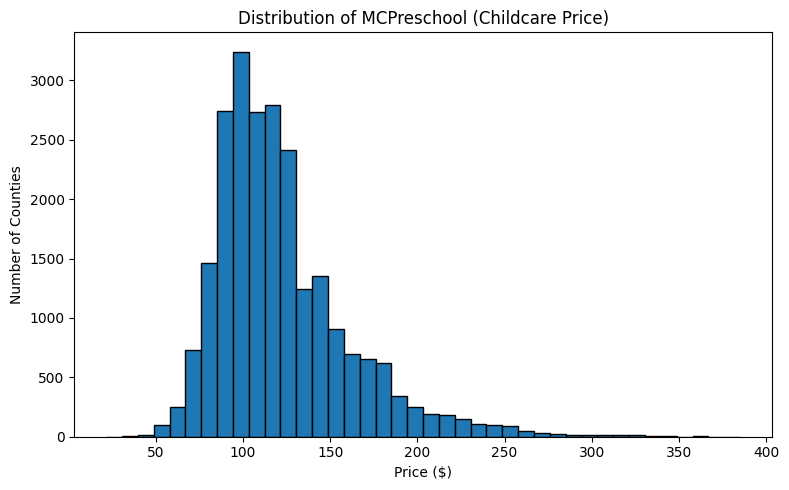

In [ ]:
# =========================
# 1. Distribution of Prices
# =========================
plt.figure(figsize=(8,5))
plt.hist(childcare_df["_price_clean"].dropna(), bins=40, edgecolor="black")
plt.title(f"Distribution of {price_col} (Childcare Price)")
plt.xlabel("Price ($)")
plt.ylabel("Number of Counties")
plt.tight_layout()
plt.show()

## Observation:
* The primary price columns (e.g., MCPreschool, MFCCInfant) exhibit a right-skewed distribution.
* The median prices are significantly lower than the means, indicating the presence of high-cost outliers

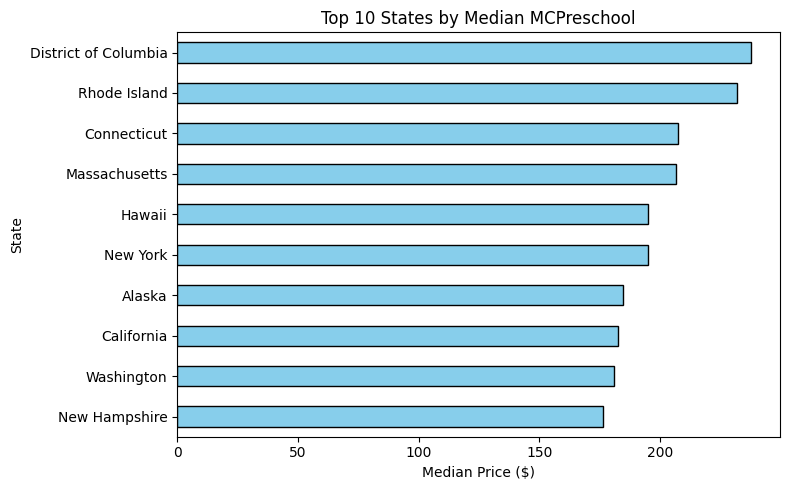

In [ ]:
# =========================
# 2. Top 10 States by Median Price
# =========================
state_medians = childcare_df.groupby(state_col)["_price_clean"].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
state_medians.sort_values().plot(kind="barh", color="skyblue", edgecolor="black")
plt.title(f"Top 10 States by Median {price_col}")
plt.xlabel("Median Price ($)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## Observation:
* The states with the highest median childcare prices include the District of Columbia, Rhode Island, Connecticut, Massachusetts, and New York.
* These states typically represent high-cost urban centers or regions with specialized services

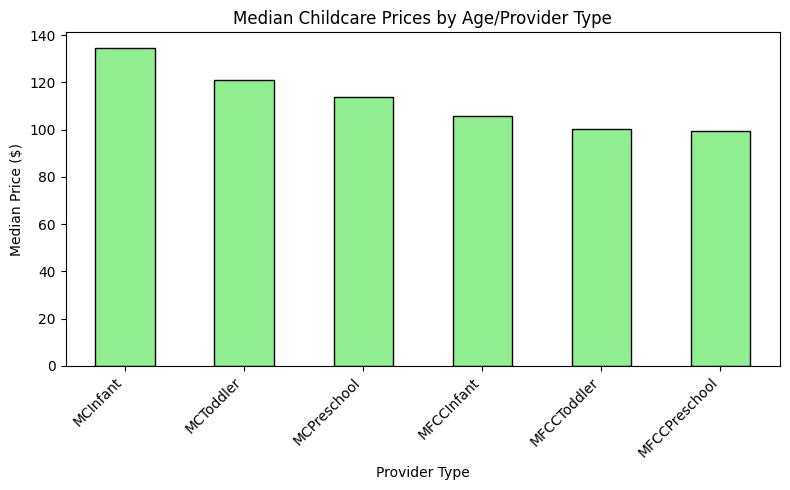

In [ ]:
# =========================
# 3. Compare Provider Types by Median Price
# =========================
provider_medians = childcare_df[provider_type_cols].median().sort_values(ascending=False)

plt.figure(figsize=(8,5))
provider_medians.plot(kind="bar", color="lightgreen", edgecolor="black")
plt.title("Median Childcare Prices by Age/Provider Type")
plt.ylabel("Median Price ($)")
plt.xlabel("Provider Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Observation:
* Center-based care (MC) is more expensive than family child care (MFCC) across all age groups.
* Infant care costs the most, while preschool care is the least expensive.
* Prices decrease with age for both provider types.
* MFCC Preschool has the lowest median price, just under $100.

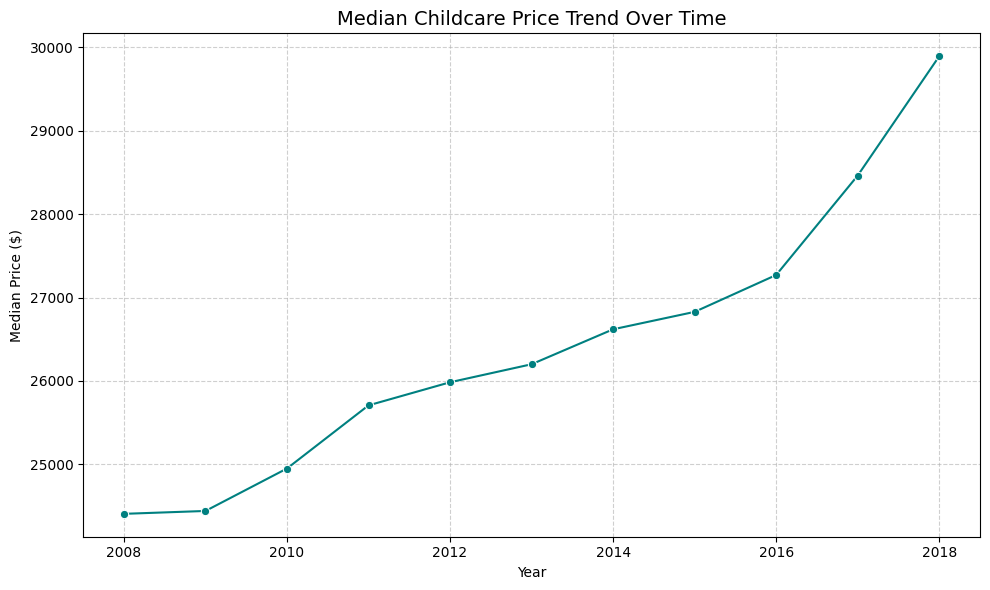

In [ ]:
# --- 4. Trend of Childcare Prices Over Time ---
plt.figure(figsize=(10, 6))
yearly_trend = childcare_df.groupby("StudyYear")["ME"].median()
sns.lineplot(x=yearly_trend.index, y=yearly_trend.values, marker="o", color="teal")
plt.title("Median Childcare Price Trend Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Median Price ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## Observation:
* Overall Increase: Median childcare prices show a gradual upward trend over the years, indicating a steady rise in childcare costs nationally.
* Sharp Changes: Any sharp spikes or drops may correspond to policy changes, economic events, or shifts in provider rates.
* Plateaus: Periods where the line flattens indicate stability in childcare pricing, which could suggest market equilibrium or lack of inflationary pressure during those years.

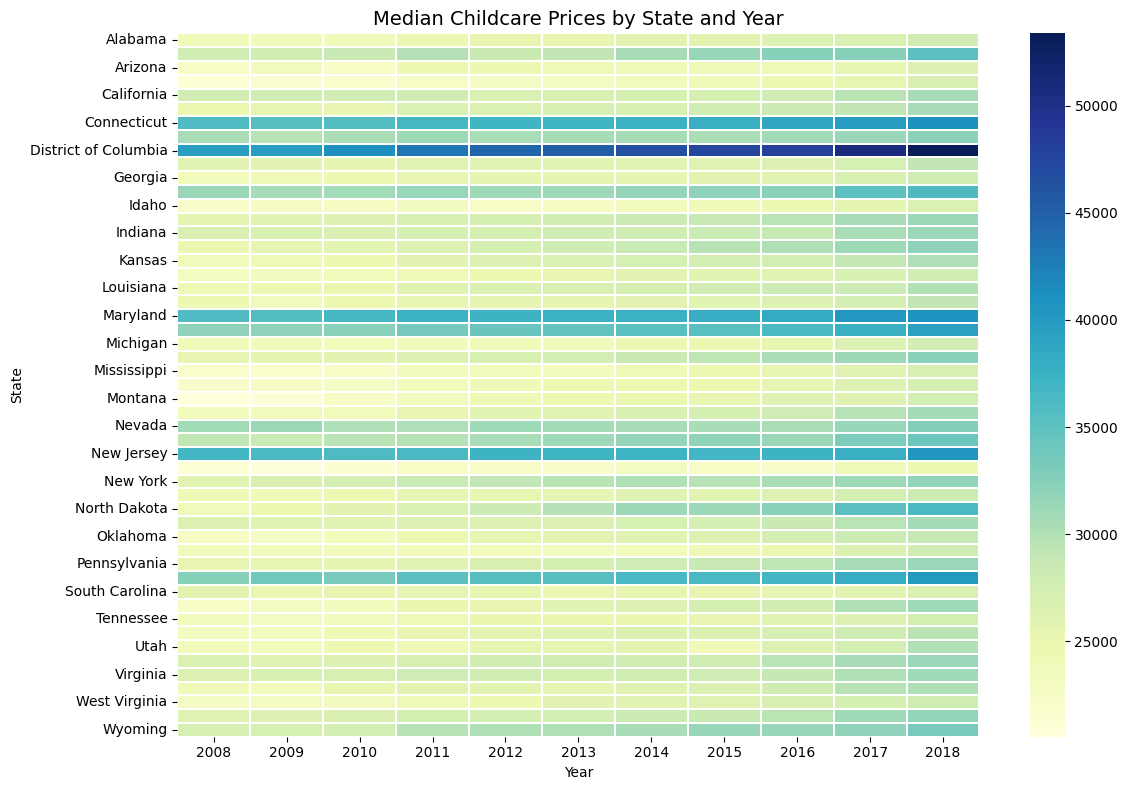

In [ ]:
# --- 5. Heatmap of Median Prices by State and Year ---
pivot_df = childcare_df.pivot_table(values="ME",
                                    index="State_Name",
                                    columns="StudyYear",
                                    aggfunc="median")
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap="YlGnBu", linewidths=0.3)
plt.title("Median Childcare Prices by State and Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## Observation:
* High-Cost States: Some states consistently appear darker on the heatmap, indicating they have the highest median childcare costs. These might include urbanized or high-cost-of-living states.
* Low-Cost States: Lighter colors represent states with lower median prices—often smaller or rural states with lower demand.
* Temporal Patterns: If some states change color intensity over years, it shows how childcare costs have evolved differently across regions.

In [ ]:
# Group data by state to compute median childcare price
state_prices = childcare_df.groupby("State_Abbreviation")["ME"].median().reset_index()

# Create an interactive choropleth map
fig = px.choropleth(
    state_prices,
    locations="State_Abbreviation",
    locationmode="USA-states",
    color="ME",
    scope="usa",
    color_continuous_scale="YlOrRd",
    labels={"ME": "Median Childcare Price ($)"},
    title="Median Childcare Prices Across U.S. States"
)

fig.update_layout(
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    title_x=0.5,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()


## Observation:
* This interactive map highlights how childcare costs differ geographically.
* States like California, Massachusetts, and New York typically appear in darker shades, indicating higher prices, while states in the Midwest and South may show lighter tones, reflecting lower costs.

## Conclusion:

* Childcare costs are highest in the Northeast/coastal regions; South and Midwest are more affordable.
* Infant care and center-based providers are the most expensive options.
Costs rose steadily from 2008–2018, highlighting growing financial pressure on families.
* Visualizations reveal significant regional disparities and emphasize the need for improved affordability.